In [53]:
from langchain_deepseek import ChatDeepSeek
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Literal
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from pydantic import Field,BaseModel
load_dotenv()  # Load environment variables from .env file

True

In [54]:
model=ChatGoogleGenerativeAI(model='gemini-3.5-flash',temperature=0.5,max_tokens=1000)

In [55]:
class SentimentSchema(BaseModel):
    sentiment:Literal['positive','negative','neutral']=Field(description="The sentiment of the text")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [56]:
structured_model=model.with_structured_output(SentimentSchema)
structured_model2=model.with_structured_output(DiagnosisSchema)

In [57]:
class ReviewState(TypedDict):
    review:str
    sentiment:Literal['positive','negative','neutral']

    diagnosis:dict
    response:str

def find_sentiment(state:ReviewState):
    prompt=f"for the for review provide the sentiment \n {state['review']}"

    sentiment=structured_model.invoke(prompt).sentiment

    return {'sentiment':sentiment}

def checkResponse(state:ReviewState)->Literal['generate_Positive_response','run_diagnosis']:
    if state['sentiment']=='positive':
        return 'generate_Positive_response'
    else:
        return 'run_diagnosis'

def generate_Positive_response(state:ReviewState):
    prompt=f"generate a positive response for the following review \n {state['review']}"
    response=model.invoke(prompt)
    return {'response':response}


def run_diagnosis(state:ReviewState):
    prompt=f"generate a diagnosis for the following review \n {state['review']} Return issue_type,tone and urgency"
    response=structured_model2.invoke(prompt)
    return {'diagnosis':response.model_dump()}

def negative_response(state:ReviewState):
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
        The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
        Write an empathetic, helpful resolution message.
        """
    response = model.invoke(prompt).content

    return {'response': response}

In [58]:
graph=StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('generate_Positive_response',generate_Positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',checkResponse)
graph.add_edge('generate_Positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow=graph.compile()

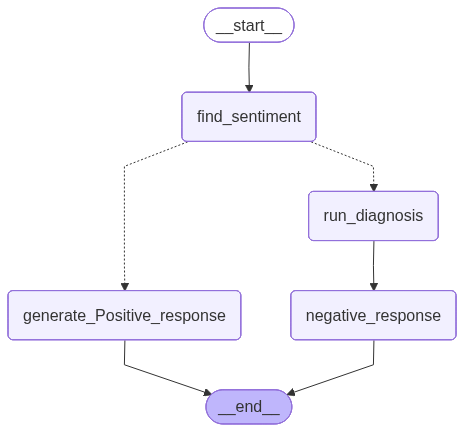

In [59]:
workflow

In [63]:
# initial_state={
#   'review':'I am really disappointed with the new update. The app keeps crashing and the performance is terrible.'
# }
initial_state={
  'review':'I am really happy with the app the app is very good.'
}
result=workflow.invoke(initial_state)

In [64]:
result

{'review': 'I am really happy with the app the app is very good.',
 'sentiment': 'positive',
 'response': AIMessage(content=[{'type': 'text', 'text': 'Here are a few options you can choose from, depending on the tone of your brand:\n\n**Option 1: Warm and friendly (Best for most apps)**\n> "Thank you so much for your kind words! We are absolutely thrilled to hear that you are happy with the app. Knowing that you’re having a great experience makes all our hard work worthwhile. Enjoy using it!"\n\n**Option 2: Short and sweet (Great for quick replies)**\n> "Thank you so much for the wonderful review! We’re so glad you’re enjoying the app. Happy using!"\n\n**Option 3: Enthusiastic and energetic**\n> "This made our day! 😍 Thank you so much for the awesome feedback. We’re incredibly happy that you love the app, and we’ll keep working hard to make it even better for you!"\n\n**Option 4: Professional**\n> "Thank you for your positive feedback! We are delighted to hear that you are happy with t